<a href="https://colab.research.google.com/github/agbaigwe/EXCEL-PROJECTS/blob/main/Another_copy_of_bankchurnanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import scipy as sp
import numpy as np

%matplotlib inline

In [ ]:
Bka = pd.read_excel('/content/Bank dataset.xlsx')

In [ ]:

Bka.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
Bka.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:

Bka.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [ ]:
Bka.isnull().sum()

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0


In [ ]:
Bka.shape

(10000, 13)

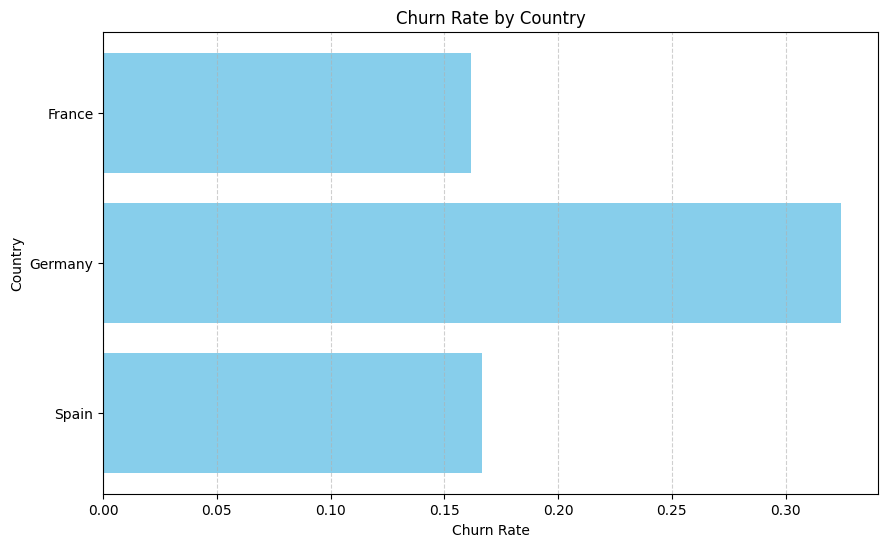

In [ ]:
# prompt: i need a lbar chart so i can see then churn by country

# Assuming 'Bka' DataFrame is already loaded and available.
# Group by country and calculate the churn rate
churn_by_country = Bka.groupby('Geography')['Exited'].mean().reset_index()

# Create the horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(churn_by_country['Geography'], churn_by_country['Exited'], color='skyblue')
plt.xlabel('Churn Rate')
plt.ylabel('Country')
plt.title('Churn Rate by Country')
plt.gca().invert_yaxis()  # Invert y-axis to show highest churn at the top
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()


<ipython-input-10-3a4985688f91>:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_age = Bka.groupby('Age_Group')['Exited'].mean().reset_index()


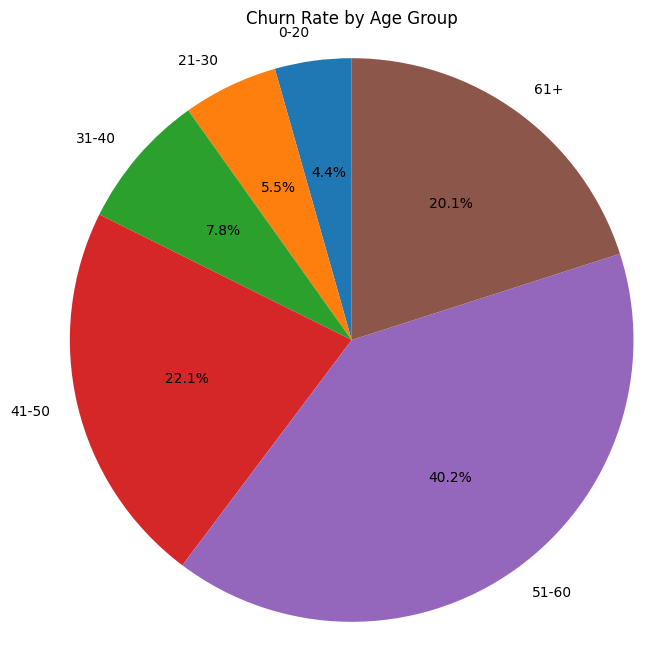

In [ ]:
# prompt: Generate churn pie chat by age group put the value on each bars

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'Bka' DataFrame is already loaded and available.

# Group by age group and calculate the churn rate
# Define age groups (you can customize these)
bins = [0, 20, 30, 40, 50, 60, 100]  # Example age bins
labels = ['0-20', '21-30', '31-40', '41-50', '51-60', '61+']
Bka['Age_Group'] = pd.cut(Bka['Age'], bins=bins, labels=labels, right=False)

churn_by_age = Bka.groupby('Age_Group')['Exited'].mean().reset_index()


# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(churn_by_age['Exited'], labels=churn_by_age['Age_Group'], autopct='%1.1f%%', startangle=90)
plt.title('Churn Rate by Age Group')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


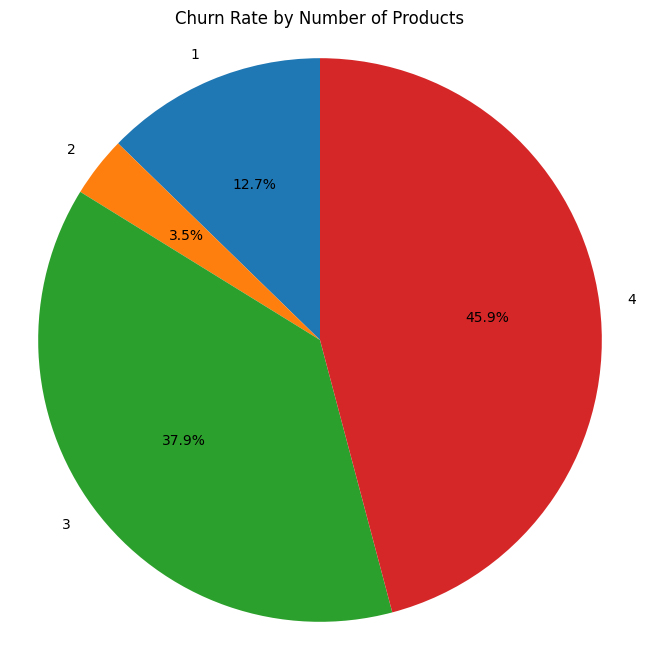

In [ ]:
# prompt: generate churn pie chat by number of products.

# Assuming 'Bka' DataFrame is already loaded and available.

# Group by the number of products and calculate the churn rate
churn_by_products = Bka.groupby('NumOfProducts')['Exited'].mean().reset_index()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(churn_by_products['Exited'], labels=churn_by_products['NumOfProducts'], autopct='%1.1f%%', startangle=90)
plt.title('Churn Rate by Number of Products')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


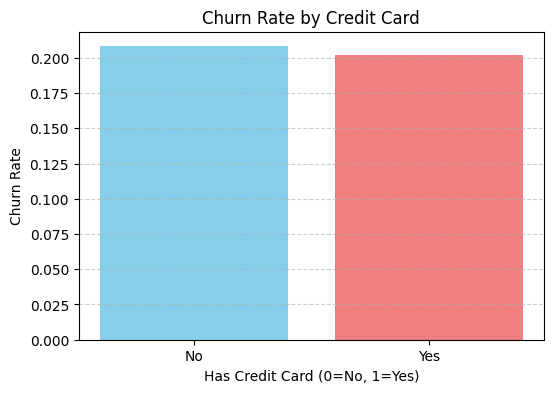

In [ ]:

# prompt: generate churn chat by creditcard

# Assuming 'Bka' DataFrame is already loaded and available.

# Group by credit card and calculate the churn rate
churn_by_card = Bka.groupby('HasCrCard')['Exited'].mean().reset_index()

# Create the bar chart
plt.figure(figsize=(6, 4))
plt.bar(churn_by_card['HasCrCard'], churn_by_card['Exited'], color=['skyblue', 'lightcoral'])
plt.xlabel('Has Credit Card (0=No, 1=Yes)')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Credit Card')
plt.xticks([0,1], ['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


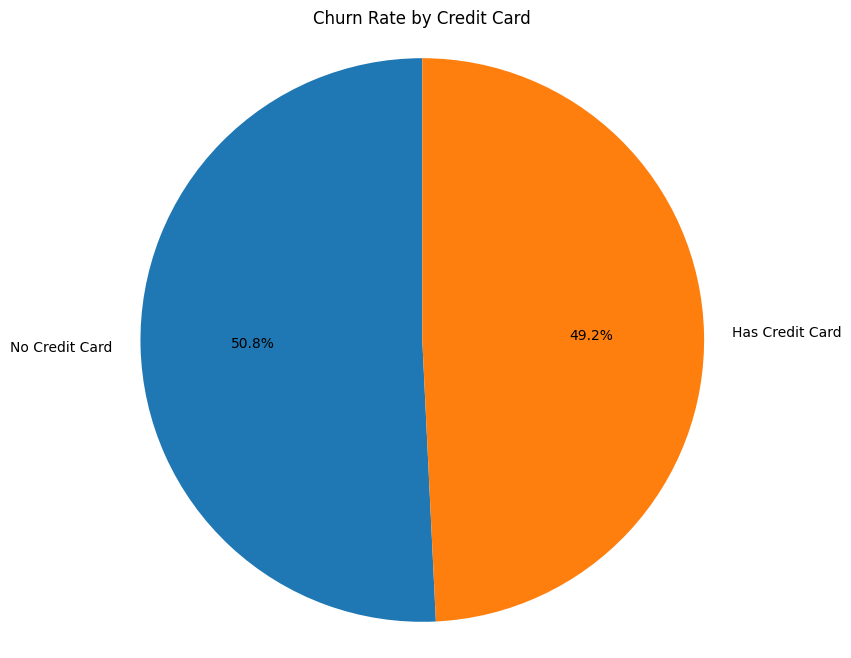

In [ ]:
# prompt: generate churn pie chat by creditcard

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'Bka' DataFrame is already loaded and available.

# Group by credit card and calculate the churn rate
churn_by_card = Bka.groupby('HasCrCard')['Exited'].mean().reset_index()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(churn_by_card['Exited'], labels=['No Credit Card', 'Has Credit Card'], autopct='%1.1f%%', startangle=90)
plt.title('Churn Rate by Credit Card')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


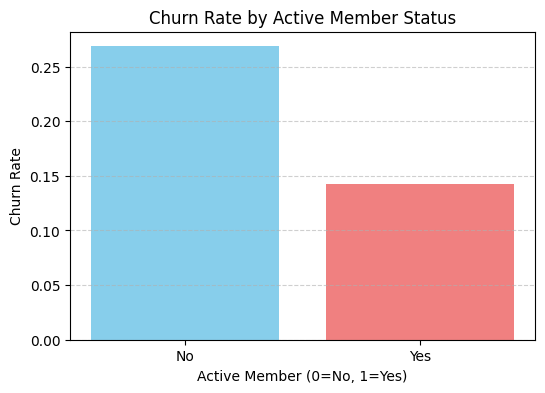

In [ ]:
# prompt: generate churn chat by active member

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'Bka' DataFrame is already loaded and available.

# Group by active member status and calculate the churn rate
churn_by_active_member = Bka.groupby('IsActiveMember')['Exited'].mean().reset_index()

# Create the bar chart
plt.figure(figsize=(6, 4))
plt.bar(churn_by_active_member['IsActiveMember'], churn_by_active_member['Exited'], color=['skyblue', 'lightcoral'])
plt.xlabel('Active Member (0=No, 1=Yes)')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Active Member Status')
plt.xticks([0, 1], ['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


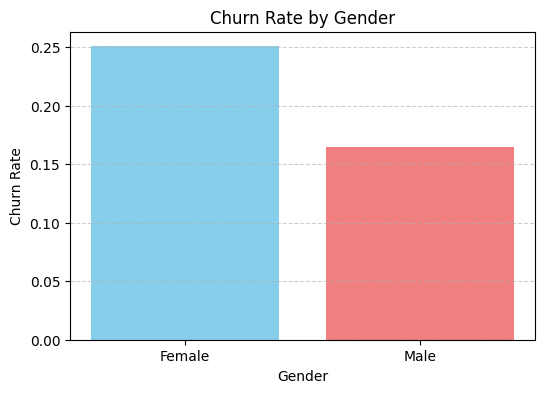

In [ ]:
# prompt: generate churn chat by gender

# Assuming 'Bka' DataFrame is already loaded and available.

# Group by gender and calculate the churn rate
churn_by_gender = Bka.groupby('Gender')['Exited'].mean().reset_index()

# Create the bar chart
plt.figure(figsize=(6, 4))
plt.bar(churn_by_gender['Gender'], churn_by_gender['Exited'], color=['skyblue', 'lightcoral'])
plt.xlabel('Gender')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Gender')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


<ipython-input-16-f0ddff0d2517>:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_creditscore = Bka.groupby('CreditScoreCategory')['Exited'].mean().reset_index()


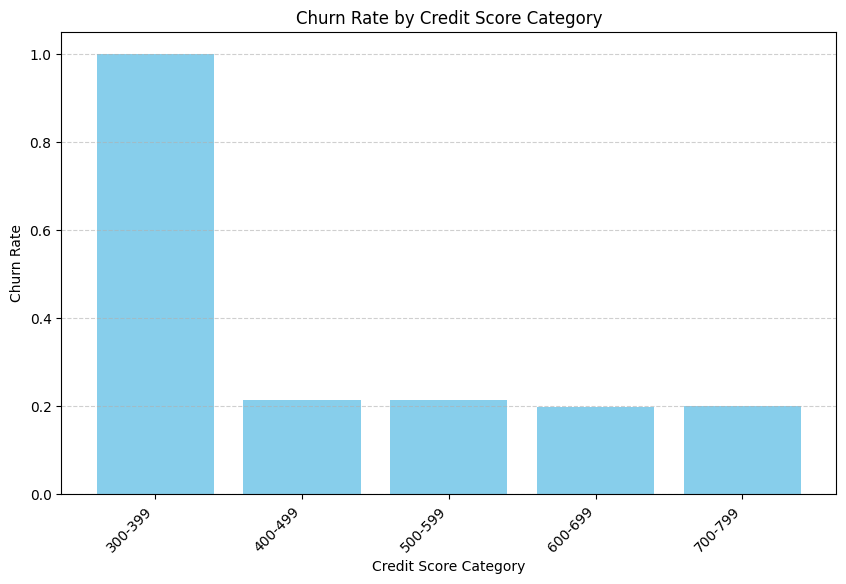

<ipython-input-16-f0ddff0d2517>:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_creditscore_binary = Bka.groupby('CreditScoreCategory')['Churn_Binary'].mean().reset_index()


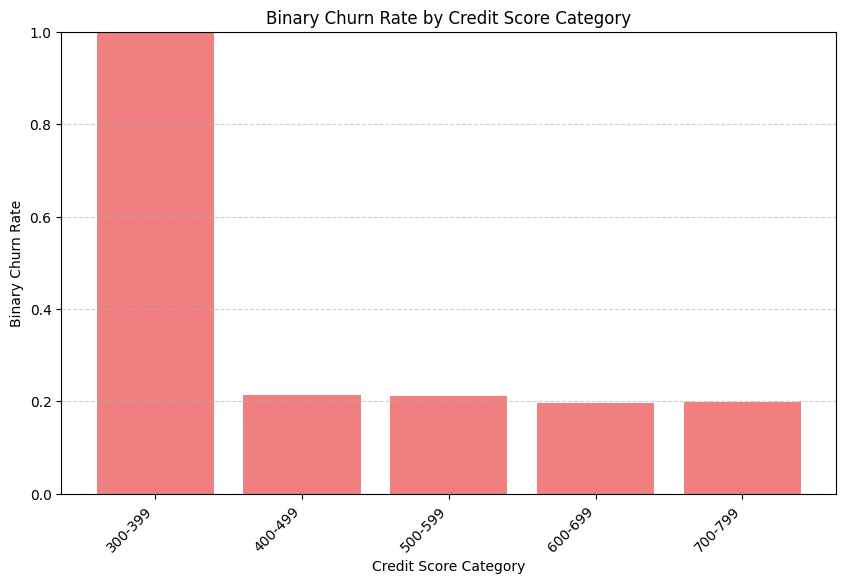

In [ ]:
# prompt: generate churn chat by creditscore make the churn axis only 0 and 1

# Assuming 'Bka' DataFrame is already loaded and available.

# Group by credit score and calculate the churn rate
# Convert CreditScore to categories for better visualization
Bka['CreditScoreCategory'] = pd.cut(Bka['CreditScore'], bins=range(300, 900, 100), right=False, labels=[f'{i}-{i+99}' for i in range(300,800,100)])

churn_by_creditscore = Bka.groupby('CreditScoreCategory')['Exited'].mean().reset_index()


# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(churn_by_creditscore['CreditScoreCategory'], churn_by_creditscore['Exited'], color='skyblue')
plt.xlabel('Credit Score Category')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Credit Score Category')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Further analysis -  creating a binary churn variable based on a threshold.
#Example: if churn rate is above 0.2, then assign churn = 1; else 0
threshold = 0.2
Bka['Churn_Binary'] = np.where(Bka['Exited'] > threshold, 1, 0)


# Group by CreditScoreCategory and calculate the churn rate (binary)
churn_by_creditscore_binary = Bka.groupby('CreditScoreCategory')['Churn_Binary'].mean().reset_index()

# Create the bar chart for binary churn
plt.figure(figsize=(10, 6))
plt.bar(churn_by_creditscore_binary['CreditScoreCategory'], churn_by_creditscore_binary['Churn_Binary'], color='lightcoral')
plt.xlabel('Credit Score Category')
plt.ylabel('Binary Churn Rate') # Y-axis label changed for clarity
plt.title('Binary Churn Rate by Credit Score Category')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, 1)  # Set y-axis limits to 0 and 1
plt.show()



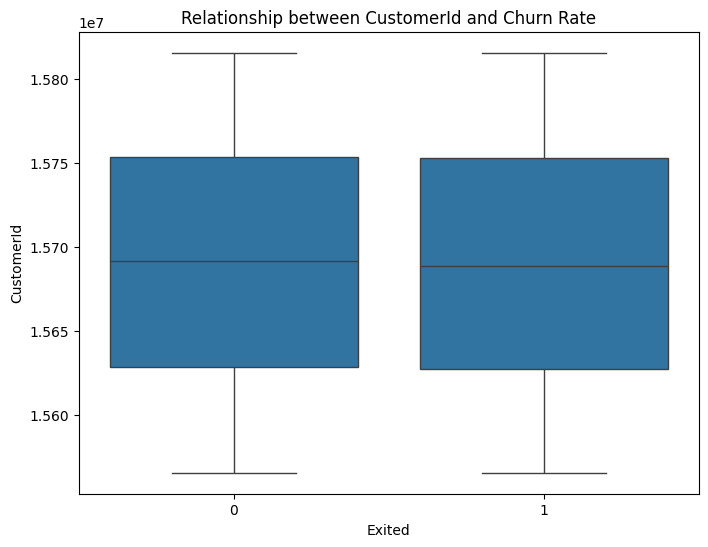

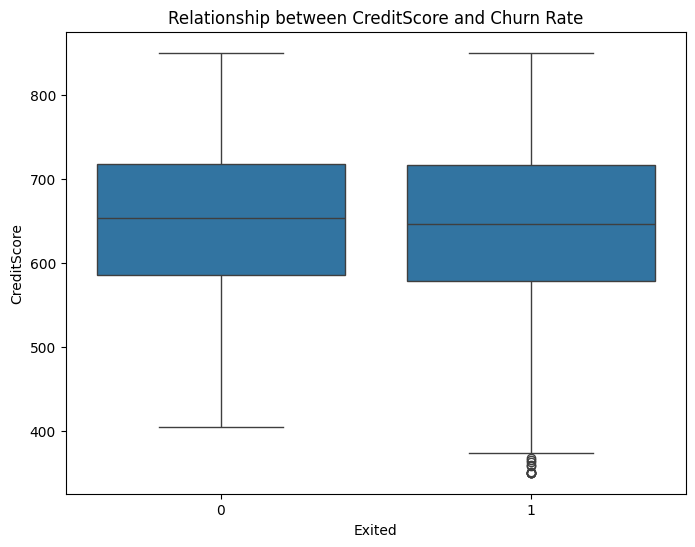

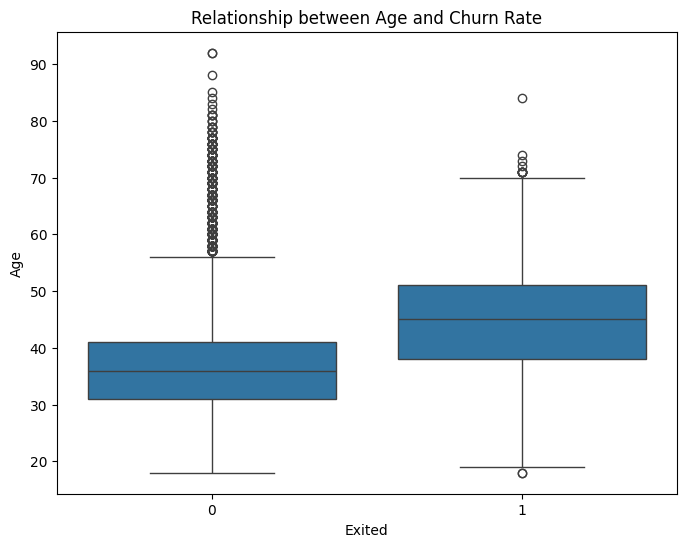

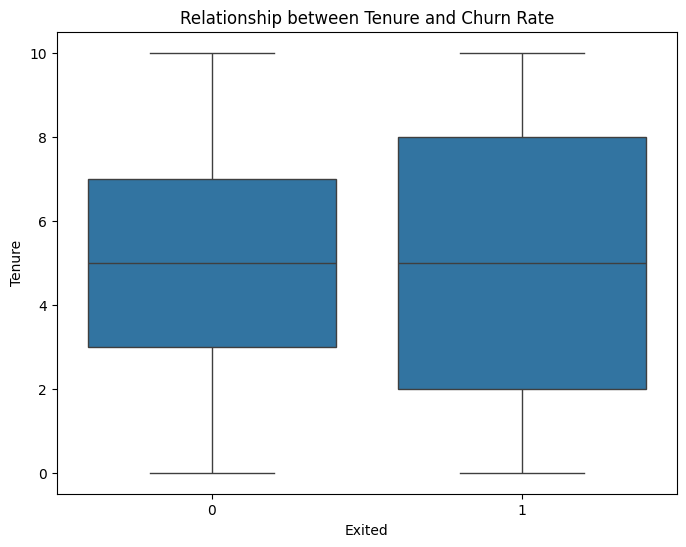

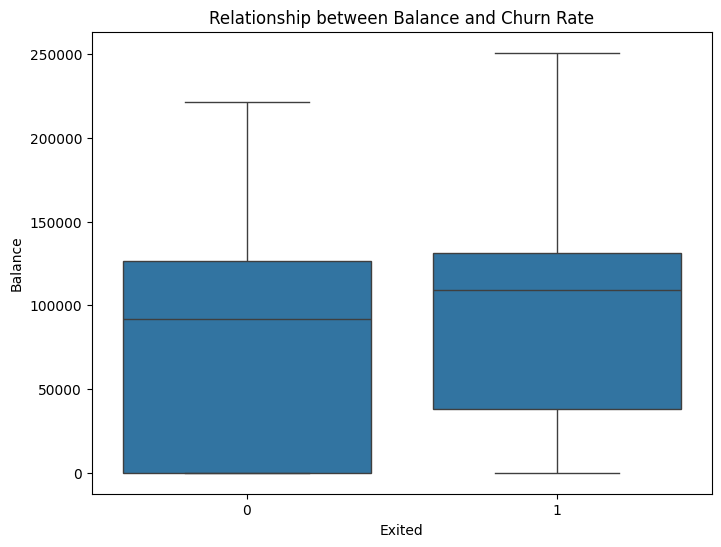

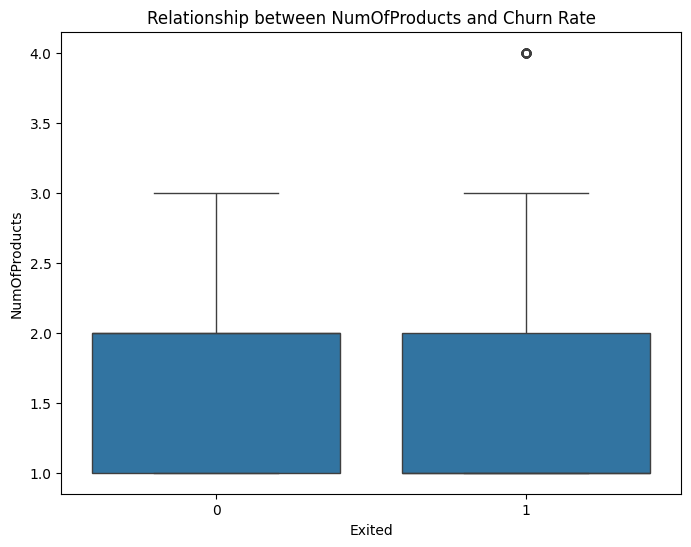

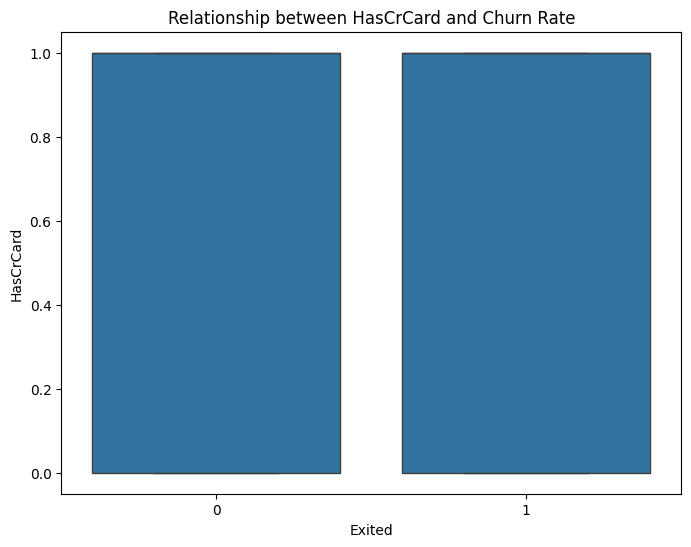

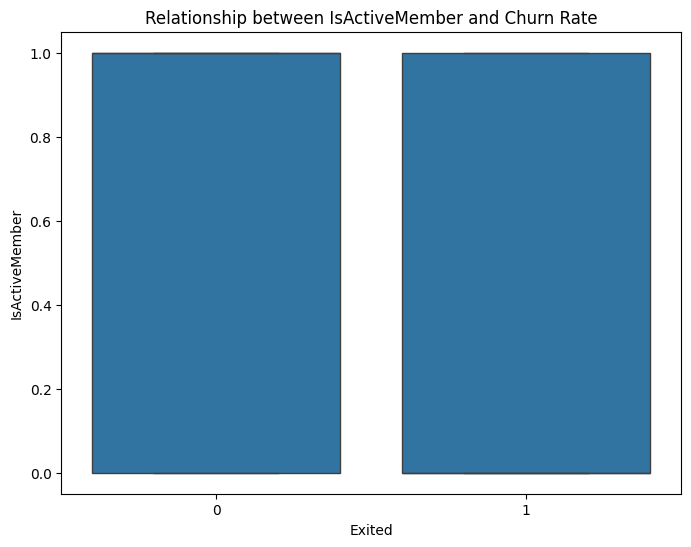

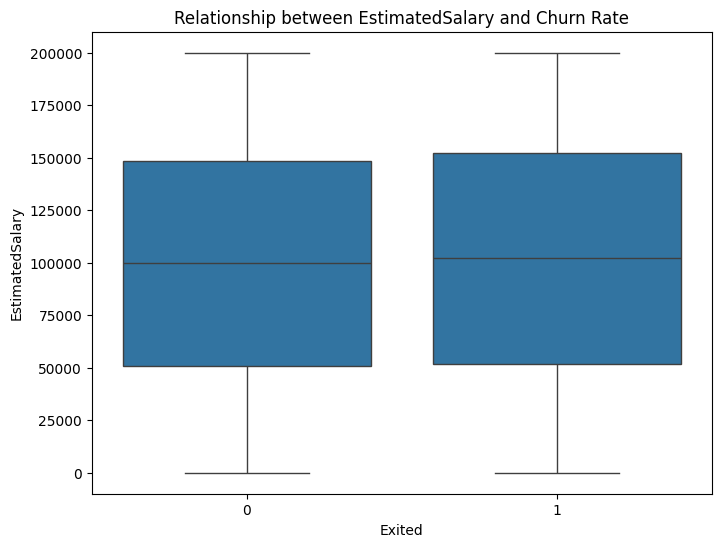

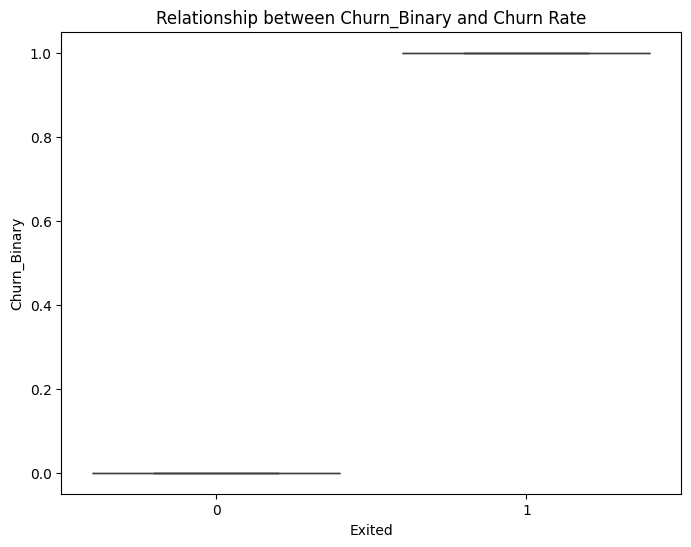

In [ ]:
# prompt: show the relationship of all numeric column with the churn rate

# Assuming 'Bka' DataFrame is already loaded and available.

numeric_cols = Bka.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop('Exited') #drop churn rate as it is not a predictor

for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sb.boxplot(x='Exited', y=col, data=Bka)
    plt.title(f'Relationship between {col} and Churn Rate')
    plt.show()


In [ ]:
Bka.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Age_Group', 'CreditScoreCategory',
       'Churn_Binary'],
      dtype='object')

In [ ]:
Bkac = Bka.drop(['CustomerId','Surname'], axis = 1)

In [ ]:

Bkae = pd.get_dummies(Bkac, columns=['Geography', 'Gender'], drop_first=True)

Bkae[['Geography_Spain','Geography_Germany', 'Gender_Male']] = Bkae[['Geography_Spain','Geography_Germany', 'Gender_Male']].astype(int)

In [ ]:
Bkae.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,CreditScoreCategory,Churn_Binary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,41-50,600-699,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,41-50,600-699,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,41-50,500-599,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,31-40,600-699,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,41-50,NaN,0,0,1,0


In [ ]:
# prompt: Using dataframe Bkae: drop the following colunms age_group,creditscorecategetory,churn_binary

# Drop the specified columns from the DataFrame.
Bkae = Bkae.drop(columns=['Age_Group', 'CreditScoreCategory', 'Churn_Binary'])
# Print the updated DataFrame to verify changes.
#print(Bkae.head())


In [ ]:
# prompt: I want to represent the columns geography and gender in an encoded in binary format
# using dummies so i can use my machine learning on it.

# Assuming 'Bka' DataFrame is already loaded and available.
Bkad = pd.get_dummies(Bka, columns=['Geography', 'Gender'], drop_first=True)
Bkad.head()


,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,CreditScoreCategory,Churn_Binary,Geography_Germany,Geography_Spain,Gender_Male
0,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,41-50,600-699,1,False,False,False
1,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,41-50,600-699,0,False,True,False
2,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,41-50,500-599,1,False,False,False
3,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,31-40,600-699,0,False,False,False
4,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,41-50,NaN,0,False,True,False


In [ ]:
Bka.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,CreditScoreCategory,Churn_Binary
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-50,600-699,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-50,600-699,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-50,500-599,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,31-40,600-699,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-50,NaN,0


In [ ]:
# prompt: I want to represent the colunms geography and gender in an encoded format so i can use my machine learning on it.

# Assuming 'Bka' DataFrame is already loaded and available.

from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'Geography' column
Bkac['Geography_Encoded'] = label_encoder.fit_transform(Bkac['Geography'])

# Fit and transform the 'Gender' column
Bkac['Gender_Encoded'] = label_encoder.fit_transform(Bkac['Gender'])

print(Bkac[['Geography', 'Geography_Encoded', 'Gender', 'Gender_Encoded']].head())


  Geography  Geography_Encoded  Gender  Gender_Encoded
0    France                  0  Female               0
1     Spain                  2  Female               0
2    France                  0  Female               0
3    France                  0  Female               0
4     Spain                  2  Female               0


In [ ]:

#Bkac["Geography"].unique()

In [ ]:
# Step 1: Isolate the 'Geography' column
#geography_column = Bka['Geography']  # or Bkac['Geography']

# Step 2: Encode the 'Geography' column
#geography_encoded = pd.get_dummies(geography_column, drop_first=True)

# Step 3: Combine the encoded column back with the original DataFrame
# Drop the original 'Geography' column
#Bkac = Bka.drop(['CustomerId','Surname','Geography'], axis=1) #drop Geography column here

# Concatenate the encoded columns with the original DataFrame
#Bkac = pd.concat([Bkac, geography_encoded], axis=1)


In [ ]:
import pandas as pd

# ... (previous code) ...

# Step 1 & 2: Modify Geography encoding
#Bkac['Geography_Germany_Spain'] = Bka['Geography'].apply(lambda x: 1 if x in ['Germany', 'Spain'] else 0)

# Step 3: Drop the original 'Geography' column (if still present)
#Bkac = Bka.drop(['CustomerId','Surname','Geography'], axis=1) #drop Geography column here


# ... (rest of the code) ...



In [ ]:
Bkac.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,CreditScoreCategory,Churn_Binary,Geography_Encoded,Gender_Encoded
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-50,600-699,1,0,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-50,600-699,0,2,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-50,500-599,1,0,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,31-40,600-699,0,0,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-50,NaN,0,2,0


In [ ]:
# prompt: Using dataframe Bkac: view the encoding format of the geography and their corresponding encoded numbers

# Display unique Geography values and their corresponding encoded numbers (if any).
# Assuming label encoding was applied.  If a different encoding was used,
# you'll need to adjust this code accordingly.

# Create a mapping of unique Geography values to their encoded values
geography_mapping = Bkac[['Geography']].drop_duplicates().reset_index(drop=True)

# If you have a separate encoded column, uncomment the next lines and replace 'Encoded_Geography'
# geography_mapping['Encoded_Geography'] = some_encoded_column
# print(geography_mapping)

geography_mapping


['France' 'Spain' 'Germany']


Handling **imbalance**

In [ ]:
Bkae['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


<Axes: xlabel='Exited', ylabel='count'>

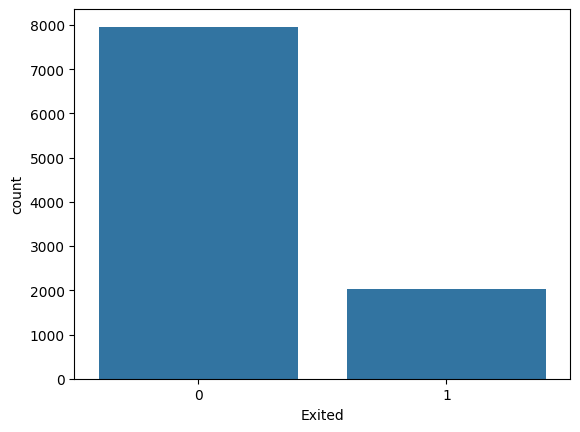

In [ ]:
sb.countplot(x='Exited', data=Bkae)

In [ ]:

X = Bkae.drop('Exited', axis=1)
y = Bkae['Exited']

In [ ]:
from imblearn.over_sampling import SMOTE


In [ ]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [ ]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [ ]:
# Step 1: Check for NaN values
print("NaN values in X:\n", X.isnull().sum())
print("NaN values in y:\n", y.isnull().sum())

NaN values in X:
 CreditScore          0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Geography_Germany    0
Geography_Spain      0
Gender_Male          0
dtype: int64
NaN values in y:
 0


In [ ]:
# Option 1: Remove rows with NaN values
#X = X.dropna()
#y = y[X.index]  # Align y with the remaining rows in X

In [ ]:
X_rs,y_rs = SMOTE().fit_resample(X,y)

In [ ]:
y_rs.value_counts()

,count
Exited,
1,7963
0,7963


**Training** and **testing**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_rs, y_rs, test_size=0.2, random_state=42)

**Feature** **Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc = StandardScaler()

In [ ]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
X_train

array([[-0.30020406, -0.59497241,  0.80585865, ..., -0.57722942,
        -0.46413027, -0.84183786],
       [ 1.09990281,  0.10946507, -1.40392163, ..., -0.57722942,
        -0.46413027,  1.1878772 ],
       [-0.71586079, -0.29307064,  1.54245207, ..., -0.57722942,
        -0.46413027, -0.84183786],
       ...,
       [ 0.20295935,  0.21009899,  1.17415536, ..., -0.57722942,
        -0.46413027,  1.1878772 ],
       [-0.68304578,  1.21643824,  0.06926522, ..., -0.57722942,
        -0.46413027, -0.84183786],
       [ 0.53110939,  1.01517039, -1.40392163, ...,  1.73241343,
        -0.46413027,  1.1878772 ]])

**Logistic regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression()

In [ ]:

lr.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pd = lr.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
#classification_report, confusion_matrix

In [ ]:
accuracy_score(y_test, y_pd)

0.7831136220966729

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
precision_score(y_test, y_pd)

0.7720959595959596

In [ ]:
recall_score(y_test, y_pd)

0.7875080489375402

In [ ]:
f1_score(y_test, y_pd)

0.779725852725534

**SVC**

In [ ]:
from sklearn import svm

In [ ]:
sm = svm.SVC()

In [ ]:
sm.fit(X_train, y_train)

SVC()

In [ ]:

y_pd1 = sm.predict(X_test)

In [ ]:

accuracy_score(y_test, y_pd1)

0.8370998116760828

In [ ]:
precision_score(y_test, y_pd1)

0.8309859154929577

In [ ]:
recall_score(y_test, y_pd1)

0.8358016741790084

In [ ]:
f1_score(y_test, y_pd1)

0.8333868378812199

**Kneigbours** **classifyer**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
kn = KNeighborsClassifier()

In [ ]:
kn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pd2 = kn.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pd2)

0.8188951663527935

In [ ]:
precision_score(y_test, y_pd2)

0.8008631319358817

In [ ]:
recall_score(y_test, y_pd2)

0.836445589182228

In [ ]:
f1_score(y_test, y_pd2)

0.8182677165354331

**Decision** **Tree** **Classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier()

In [ ]:
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:


y_pd3 = kn.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pd3)

0.8188951663527935

In [ ]:
precision_score(y_test, y_pd3)

0.8008631319358817

In [ ]:


recall_score(y_test, y_pd3)

0.836445589182228

In [ ]:
f1_score(y_test, y_pd3)

0.8182677165354331

**Random** **Forest** **Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier()

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pd4 = rf.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pd4)

0.8565599497802887

In [ ]:
precision_score(y_test, y_pd4)

0.8494897959183674

In [ ]:
recall_score(y_test, y_pd4)

0.8576947842884739

In [ ]:
f1_score(y_test, y_pd4)

0.8535725728933035

**Gradient** **Boosting** **Classifier**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gb = GradientBoostingClassifier()

In [ ]:

gb.fit(X_train, y_train)

GradientBoostingClassifier()

In [ ]:

y_pd5 = rf.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pd5)

0.8565599497802887

In [ ]:
precision_score(y_test, y_pd5)

0.8494897959183674

In [ ]:
recall_score(y_test, y_pd5)

0.8576947842884739

In [ ]:
f1_score(y_test, y_pd5)

0.8535725728933035

**Comparing** **The** **Best** **Model**

In [ ]:
Final_data = pd.DataFrame({
    'Models': ['lr', 'sm', 'kn', 'dt', 'rf', 'gb'],  # Only 5 models to match 5 accuracy scores
    'ACC': [
        accuracy_score(y_test, y_pd),
        accuracy_score(y_test, y_pd1),
        accuracy_score(y_test, y_pd2),
        accuracy_score(y_test, y_pd3),
        accuracy_score(y_test, y_pd4),
        accuracy_score(y_test, y_pd5)
    ]
})


In [ ]:

Final_data

,Models,ACC
0,lr,0.783114
1,sm,0.837100
2,kn,0.818895
3,dt,0.818895
4,rf,0.856560
5,gb,0.856560


In [ ]:
Final_data1 = pd.DataFrame({
    'Models': ['lr', 'sm', 'kn', 'dt', 'rf', 'gb'],  # Only 5 models to match 5 accuracy scores
    'PRE': [
        precision_score(y_test, y_pd),
       precision_score(y_test, y_pd1),
        precision_score(y_test, y_pd2),
        precision_score(y_test, y_pd3),
      precision_score(y_test, y_pd4),
        precision_score(y_test, y_pd5)]})

In [ ]:
Final_data1

,Models,PRE
0,lr,0.772096
1,sm,0.830986
2,kn,0.800863
3,dt,0.800863
4,rf,0.849490
5,gb,0.849490


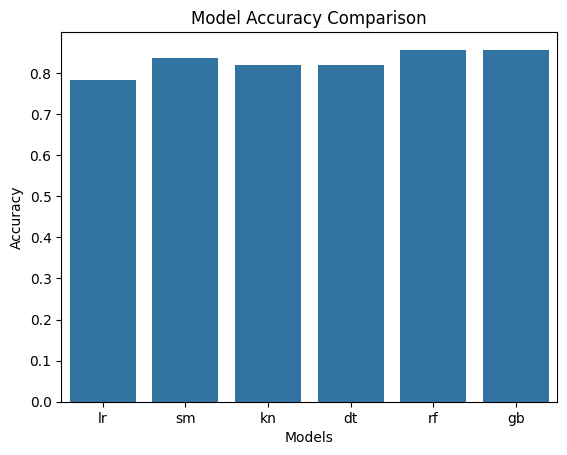

In [ ]:
# Create the bar plot
sb.barplot(x='Models', y='ACC', data=Final_data)

# Add labels and title
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')

# Display the plot
plt.show()

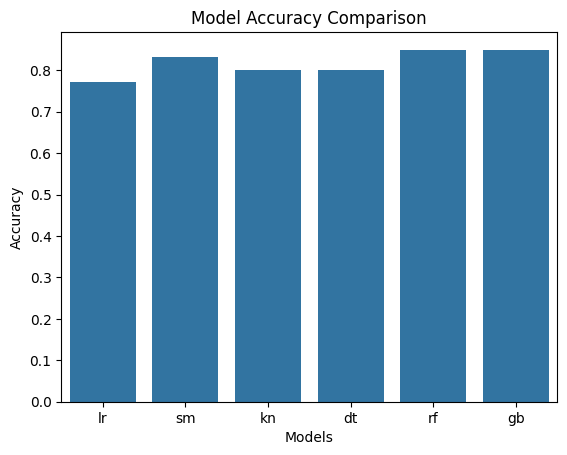

In [ ]:
# Create the bar plot
sb.barplot(x='Models', y='PRE', data=Final_data1)

# Add labels and title
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')

# Display the plot
plt.show()

**Save** **The** **Model**

In [ ]:

X_rs = sc.fit_transform(X_rs)

In [ ]:

rf.fit(X_rs, y_rs)

RandomForestClassifier()

In [ ]:
import joblib

In [ ]:
joblib.dump(rf, 'churn_predict_model')

['churn_predict_model']

In [ ]:
model = joblib.load('churn_predict_model')

In [ ]:
Bkae.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')

In [ ]:
# Your input data as a 1D array
input_data = np.array([772, 42, 3, 75075.31, 2, 1, 0, 92888.52, 1, 0, 1])

# Reshape the input data into a 2D array
input_data_2d = input_data.reshape(1, -1)

# Now pass the reshaped data to the model
prediction = model.predict(input_data_2d)

print(prediction)

[1]
